# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260520-28836-qcodes.log
Experiment loaded. Last ID no: 271


In [4]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [8]:
params.device_line_1_name

'R9C9'

Negative voltages for this device due to polarity of four wire connection

Text(0.5, 1.0, 'Voltage vs Current\nID 41 2026-05-12 15:01:08')

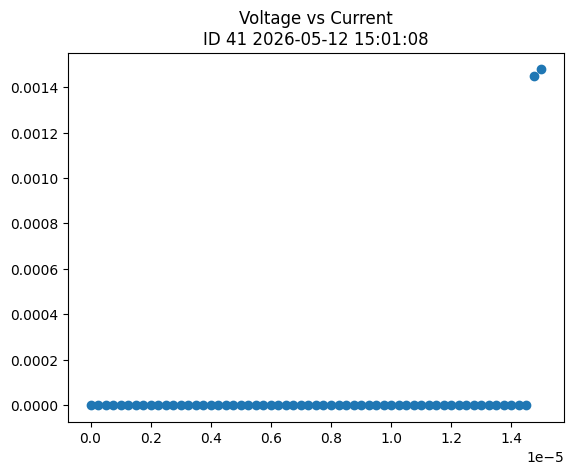

In [482]:
ID = params.device_line_1['IDs']['critical_current']
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(-current, -voltage, 'o')
plt.title(params.make_title(ID=ID, title='Voltage vs Current'))

Text(0.5, 1.0, 'Counts vs Current\nID 80 2026-05-13 13:09:16\n5V')

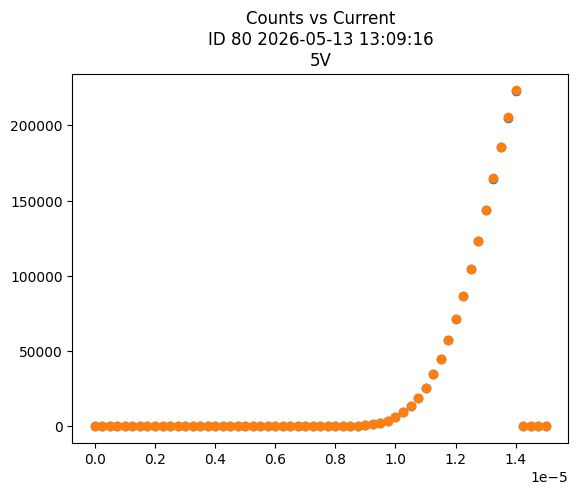

In [483]:
ID = params.device_line_1['IDs']['light_counts']
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['yoko_current']['yoko_current']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Counts vs Current', extra = '5V'))

# Dark Counts vs Current 

3660


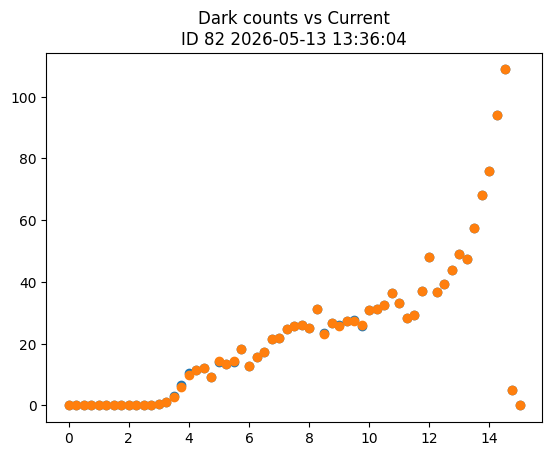

In [414]:
ID = params.device_line_1['IDs']['dark_counts']
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['yoko_current']['yoko_current']
plt.plot(-current*1e6, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current*1e6, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Dark counts vs Current'))
print(len(current))

In [94]:
len(CR1[~np.isnan(CR1)])

61

In [ ]:
current

# SDE 

In [75]:
Nphotons = load_by_id(params.Nphotons_ID).get_parameter_data()['Nphotons']['Nphotons']

In [76]:
v_att_range = params.att_blue_v_attenuator_range
v_att = np.arange(v_att_range['start'], v_att_range['stop'], v_att_range['step'])

In [77]:
len(v_att), len(Nphotons)

(43, 43)

In [78]:
v_att[-11] # Choose 5V

np.float64(4.999999999999995)

Text(0.5, 1.0, 'SDE vs Current (5V)\nID 80 2026-05-13 13:09:16')

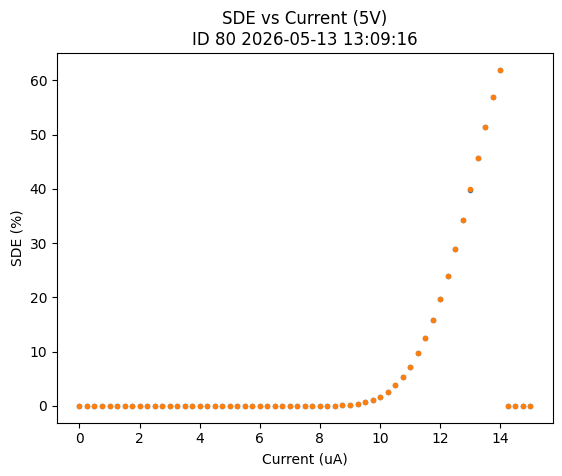

In [488]:
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5v = Nphotons[-11]
IDlcr = params.device_line_1['IDs']['light_counts']
currents = load_by_id(IDlcr).get_parameter_data()['yoko_current']['yoko_current']
light_counts1 = load_by_id(IDlcr).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDlcr).get_parameter_data()['CR2']['CR2']

IDdcr = params.device_line_1['IDs']['dark_counts']
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1']
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2']

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5v
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE1, '.')
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Current (uA)')
plt.title(params.make_title(ID=IDlcr, title='SDE vs Current (5V)'))


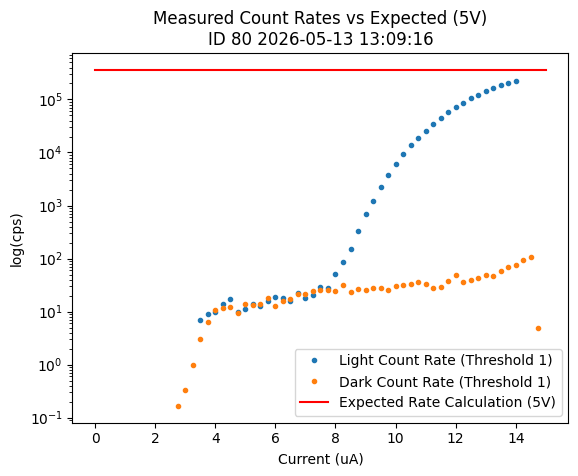

In [504]:
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5v = Nphotons[-11]
IDlcr = params.device_line_1['IDs']['light_counts']
currents = load_by_id(IDlcr).get_parameter_data()['yoko_current']['yoko_current']
light_counts1 = load_by_id(IDlcr).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDlcr).get_parameter_data()['CR2']['CR2']

IDdcr = params.device_line_1['IDs']['dark_counts']
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1']
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2']

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5v
plt.semilogy(-currents[~np.isnan(currents)]*1e6, light_counts1[~np.isnan(light_counts1)], '.', label='Light Count Rate (Threshold 1)')
plt.semilogy(-currents[~np.isnan(currents)]*1e6, dark_counts1[~np.isnan(dark_counts1)], '.', label='Dark Count Rate (Threshold 1)')
Nphotonsline = np.ones_like(dark_counts1[~np.isnan(dark_counts1)])*Nphotons_5v
plt.semilogy(-currents[~np.isnan(currents)]*1e6, Nphotonsline, 'r-', label='Expected Rate Calculation (5V)')
plt.ylabel('log(cps)')
plt.xlabel('Current (uA)')
plt.title(params.make_title(ID=IDlcr, title='Measured Count Rates vs Expected (5V)'))
plt.legend()

# Counts vs Attenuation

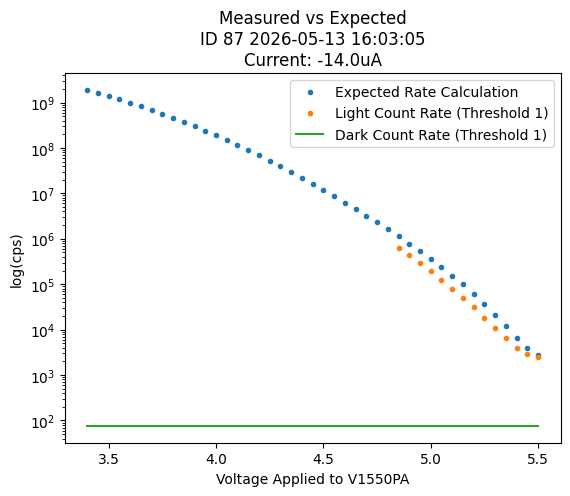

In [508]:
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']

ID = params.device_line_1['IDs']['counts_vs_attenuation']['run1']
current = load_by_id(ID).get_parameter_data()['yoko_current']['yoko_current']
v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], 
                         params.att_blue_v_attenuator_range['stop'],  
                         params.att_blue_v_attenuator_range['step'])
light_counts1 = load_by_id(ID).get_parameter_data()['CR1']['CR1']

dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA


plt.semilogy(v_attenuator[::-1], Nphotons[::-1], '.', label='Expected Rate Calculation')
plt.semilogy(v_attenuator[::-1], light_counts1[~np.isnan(light_counts1)], '.', label='Light Count Rate (Threshold 1)')

dcr1line = np.ones_like(Nphotons[::-1])*dark_counts1
plt.semilogy(v_attenuator[::-1], dcr1line, '-', label='Dark Count Rate (Threshold 1)')

plt.ylabel('log(cps)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
plt.title(params.make_title(ID=ID, title='Measured vs Expected', extra=f'Current: {current[0]*1e6}uA'))
plt.legend()

In [552]:
IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2'] + params.device_line_1['IDs']['counts_vs_attenuation']['run3']  +  params.device_line_1['IDs']['counts_vs_attenuation']['run4']
min_idx = 0
max_idx = len(IDs)-1

v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], params.att_blue_v_attenuator_range['stop'],  params.att_blue_v_attenuator_range['step'])

idx_vend, _ = params.match(5.5, v_attenuator)

def plot_counts_vs_att(idx):
    IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2'] + params.device_line_1['IDs']['counts_vs_attenuation']['run3'] +  params.device_line_1['IDs']['counts_vs_attenuation']['run4']
    IDsweep = IDs[idx]
    Nphotons = load_by_id(params.NphotonsID['vs_dB']).get_parameter_data()['Nphotons']['Nphotons']
    current = load_by_id(IDsweep).get_parameter_data()['yoko_current']['yoko_current'][0]
    light_counts1 = load_by_id(IDsweep).get_parameter_data()['CR1']['CR1'][:43]
    light_counts2 = load_by_id(IDsweep).get_parameter_data()['CR2']['CR2'][:43]
    # total_counts = load_by_id(ID).get_parameter_data()['counts1']['counts1'][:43]
    
    # Get idx of dark counts corresponding to the current in this sweep 
    dcr_currents = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
    idx,curr_out = params.match(current, dcr_currents)
    # Get dark counts values 
    dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA
    dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2'][idx]
    
    SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons[::-1]
    SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons[::-1]
    plt.plot(v_attenuator[::-1], 100*SDE1, '.')
    plt.plot(v_attenuator[::-1], 100*SDE2, '.')
    plt.ylabel('SDE (%)')
    plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
    plt.title(f'{params.device_line_1['name']} Ibias={current}\n{100*max(SDE1):.2f}%\n ID {IDsweep}')
    plt.title(params.make_title(ID=IDsweep, title='SDE vs Attenuation', extra=f'Ibias={current}\nmax {100*max(SDE1):.2f}%'))

interact(plot_counts_vs_att, idx=IntSlider(min=min_idx, max=max_idx, step=1, value=min_idx,
                                  continuous_update=False));


Check match:5.5 (test) = [5.5]?


interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=13), Output(outputs=(…

In [538]:
Nphotons = load_by_id(params.Nphotons_ID).get_parameter_data()['Nphotons']['Nphotons']

IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2']
IDsweep = IDs[0]
current = load_by_id(IDsweep).get_parameter_data()['yoko_current']['yoko_current'][0]
v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], params.att_blue_v_attenuator_range['stop'],  params.att_blue_v_attenuator_range['step'])
light_counts1 = load_by_id(IDsweep).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDsweep).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDsweep).get_parameter_data()['total_counts1']['total_counts1']

# Get idx of dark counts corresponding to the current in this sweep 
dcr_currents = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
idx,curr_out = params.match(current, dcr_currents)
# Get dark counts values 
dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA
dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2'][idx]

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons[::-1]
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons[::-1]
plt.plot(v_attenuator[::-1], 100*SDE1, '.')
plt.plot(v_attenuator[::-1], 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
plt.title(f'{params.device_line_1['name']} Ibias={current}')

plt.figure()
plt.plot(v_attenuator[::-1], light_counts1[~np.isnan(light_counts1)], '.')


idx, amt = params.match(max(SDE1), SDE1, tol = 0.001)
print(total_counts1[idx])
print(light_counts1[idx])
# Minimum reset time 
print(f'Effective reset time: {1/light_counts1[idx]} (0.4ms)') # 0.4ms 
print(Nphotons[::-1][idx])
print(f'Reset time for 100% efficiency: {1/Nphotons[::-1][idx]}')
print(dark_counts1[idx])
print((light_counts1[idx]-dark_counts1[idx])/Nphotons[::-1][idx])
print(f'V: {v_attenuator[::-1][idx]}\n')

v_att = v_attenuator[::-1]
idx = 10

print(f'V: {v_attenuator[::-1][idx]}')
print(light_counts1[idx])
# Minimum reset time 
print(f'Effective reset time: {1/light_counts1[idx]}') # 0.4ms 
print(Nphotons[::-1][idx])
print(f'Reset time for 100% efficiency: {1/Nphotons[::-1][idx]}')
print(dark_counts1[idx])
print((light_counts1[idx]-dark_counts1[idx])/Nphotons[::-1][idx])


AttributeError: 'snspd' object has no attribute 'Nphotons_ID'

([<Axes: title={'center': 'Run #110, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='V', ylabel='cps'>,
  <Axes: title={'center': 'Run #110, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='V', ylabel='cps'>],
 [None, None])

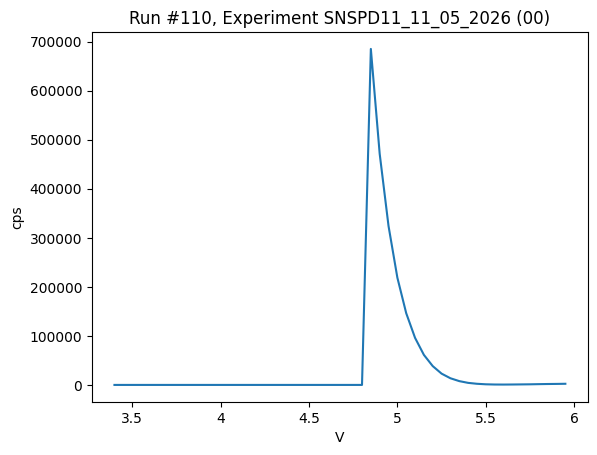

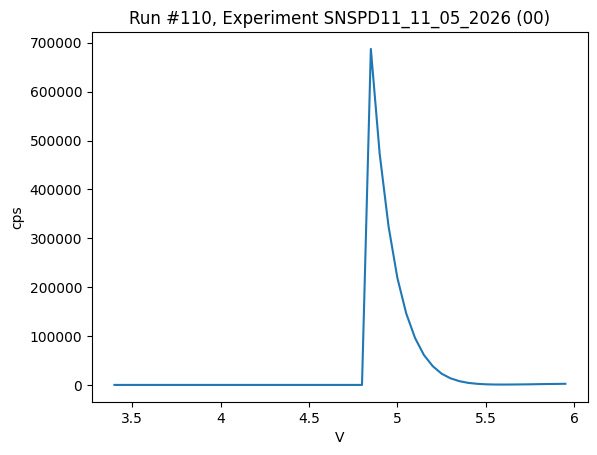

In [272]:
plot_by_id(110)

# Wavelength Sweep 

In [335]:
# Get the corresponding current 
currents_dcr = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)

Check match:-1.4e-05 (test) = [-1.4e-05]?


In [368]:
print(params.device_line_1['thresholds'])

{'range1': {'current': '-13e-6', 'threshold1': '342e-3', 'threshold2': '120e-3'}, 'range2': {'current': '-8e-6', 'threshold1': '198e-3', 'threshold2': '60e-3'}, 'range3': {'current': 0, 'threshold1': '78e-3', 'threshold2': '48e-3'}}


Check match:-1.4e-05 (test) = [-1.4e-05]?


Text(0.5, 1.0, 'SDE vs Wavelength\nID 124 2026-05-16 18:16:55\n5.5V')

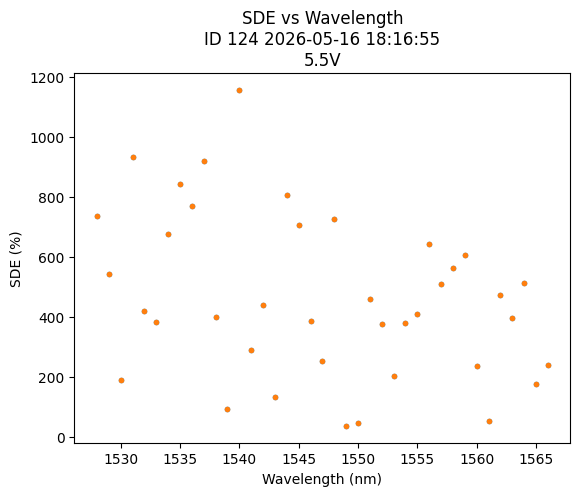

In [515]:
Nphotons = load_by_id(params.NphotonsID['vs_dB']).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5_5v = Nphotons[-1]
IDwav = params.device_line_1['IDs']['wavelength']['run5_5v']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength_range']['wavelength_range']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']

# Get the corresponding current 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]
SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5_5v
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE1, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='SDE vs Wavelength', extra='5.5V')
plt.title(title)


Check match:-1.4e-05 (test) = [-1.4e-05]?


Text(0.5, 1.0, 'Counts vs Wavelength\nID 124 2026-05-16 18:16:55\n5.5V')

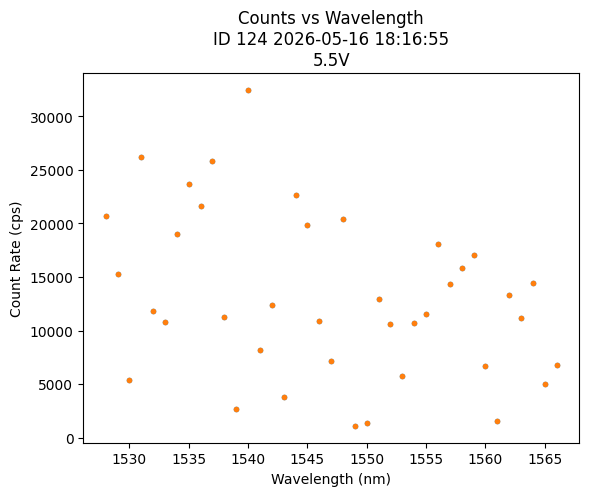

In [517]:
Nphotons = load_by_id(params.NphotonsID['vs_dB']).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5_5v = Nphotons[-1]
IDwav = params.device_line_1['IDs']['wavelength']['run5_5v']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength_range']['wavelength_range']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']

# Get the corresponding current 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]

plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts1[~np.isnan(light_counts1)], '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts2[~np.isnan(light_counts2)], '.')

plt.ylabel('Count Rate (cps)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='Counts vs Wavelength', extra='5.5V')
plt.title(title)


In [375]:
ID = params.device_line_1['IDs']['wavelength']
total_counts1 = load_by_id(ID).get_parameter_data()['total_counts1']['total_counts1']
meas_time = load_by_id(ID).get_parameter_data()['meas_time']['meas_time']

([<Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>,
  <Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>],
 [None, None])

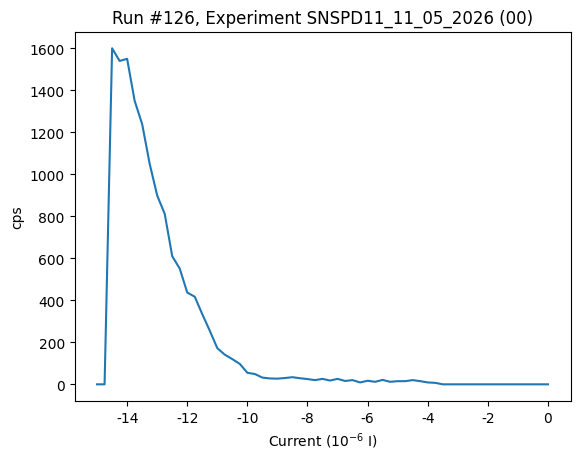

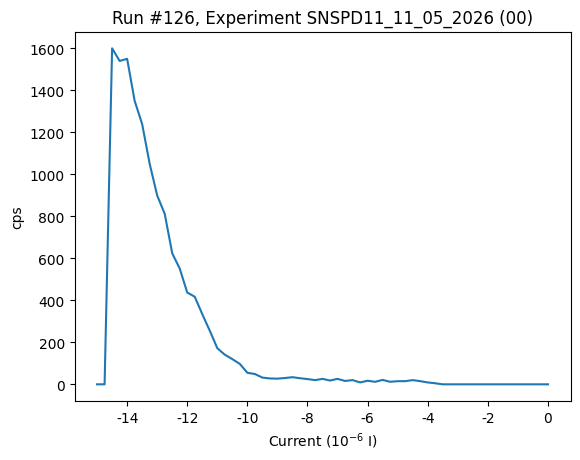

In [380]:
plot_by_id(126)

Text(0.5, 1.0, 'Counts vs Current\nID 126 2026-05-16 19:55:07\n5.5V, 1550nm')

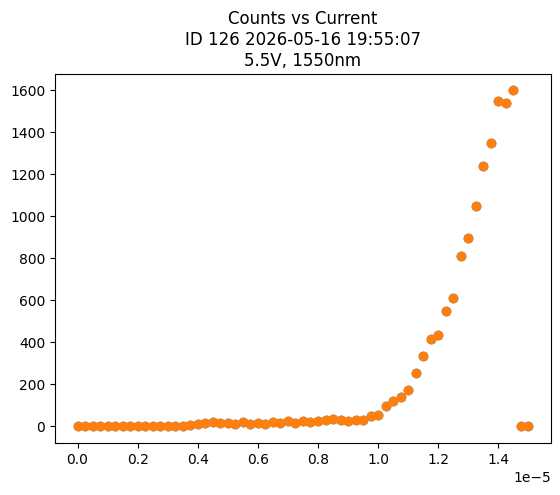

In [551]:
plt.figure()
ID = params.device_line_1['IDs']['light_counts']['run_5-5v']
data = load_by_id(ID).get_parameter_data()
plt.plot(-data['CR1']['yoko_current'], data['CR1']['CR1'], 'o')
title = params.make_title(ID=ID, title='Counts vs Current', extra='5.5V, 1550nm')
plt.title(title)

plt.plot(-data['CR1']['yoko_current'], data['CR1']['CR1'], 'o')
title = params.make_title(ID=ID, title='Counts vs Current', extra='5.5V, 1550nm')
plt.title(title)

In [546]:
data = load_by_id(IDlcr).get_parameter_data()

In [548]:
data['CR1']['yoko_current']

array([ 0.000e+00, -2.500e-07, -5.000e-07, -7.500e-07, -1.000e-06,
       -1.250e-06, -1.500e-06, -1.750e-06, -2.000e-06, -2.250e-06,
       -2.500e-06, -2.750e-06, -3.000e-06, -3.250e-06, -3.500e-06,
       -3.750e-06, -4.000e-06, -4.250e-06, -4.500e-06, -4.750e-06,
       -5.000e-06, -5.250e-06, -5.500e-06, -5.750e-06, -6.000e-06,
       -6.250e-06, -6.500e-06, -6.750e-06, -7.000e-06, -7.250e-06,
       -7.500e-06, -7.750e-06, -8.000e-06, -8.250e-06, -8.500e-06,
       -8.750e-06, -9.000e-06, -9.250e-06, -9.500e-06, -9.750e-06,
       -1.000e-05, -1.025e-05, -1.050e-05, -1.075e-05, -1.100e-05,
       -1.125e-05, -1.150e-05, -1.175e-05, -1.200e-05, -1.225e-05,
       -1.250e-05, -1.275e-05, -1.300e-05, -1.325e-05, -1.350e-05,
       -1.375e-05, -1.400e-05, -1.425e-05, -1.450e-05, -1.475e-05,
       -1.500e-05])

Text(0.5, 1.0, 'SDE vs Current (5.5V)\nID 126 2026-05-16 19:55:07')

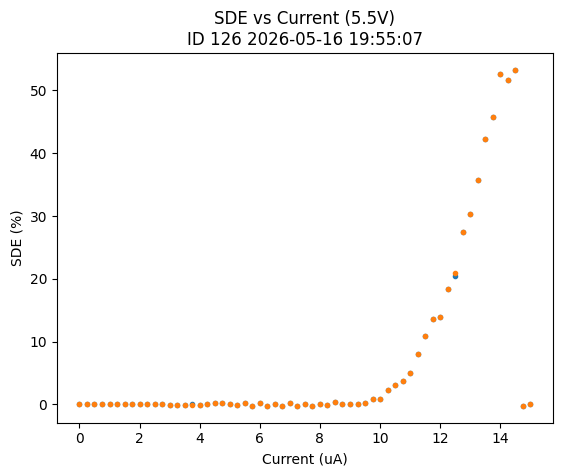

In [549]:
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']

Nphotons = load_by_id(params.NphotonsID['vs_dB']).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5_5v = Nphotons[-1]

IDlcr = params.device_line_1['IDs']['light_counts']['run_5-5v']
currents = load_by_id(IDlcr).get_parameter_data()['CR1']['yoko_current']
light_counts1 = load_by_id(IDlcr).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDlcr).get_parameter_data()['CR2']['CR2']

IDdcr = params.device_line_1['IDs']['dark_counts']
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1']
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2']

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5_5v
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE1, '.')
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Current (uA)')
plt.title(params.make_title(ID=IDlcr, title='SDE vs Current (5.5V)'))


In [426]:
data.keys()

dict_keys(['CR1', 'CR2', 'counts1', 'counts2', 'dmm_volt', 'interval', 'meas_time', 'n_captures', 'threshold1', 'threshold2', 'total_counts1', 'total_counts2', 'trace_time'])

([<Axes: title={'center': 'Run #125, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

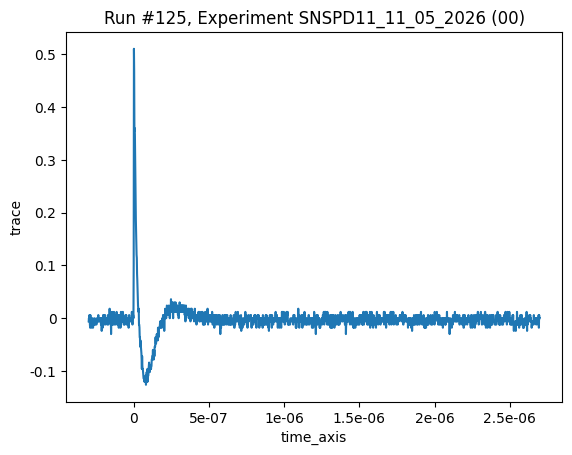

In [404]:
plot_by_id(125)

RE-calculated number of photons vs wavelength for 5.5 attenuation

Text(0, 0.5, 'Photons/sec')

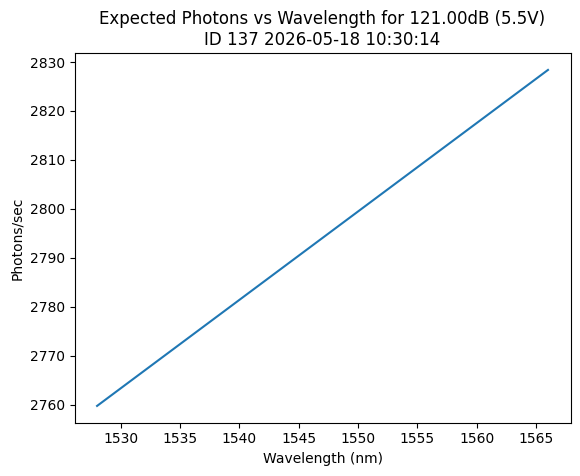

In [408]:
ID = params.Nphotons_wavID_5_5v
data = load_by_id(ID).get_parameter_data()
attenuation = data['attenuation']['attenuation']
Nphotons = data['Nphotons']['Nphotons']
wavelength = data['wavelength']['wavelength']
plt.plot(wavelength*1e9, Nphotons)
plt.title(params.make_title(ID=ID, title=f'Expected Photons vs Wavelength for {attenuation[0]:.2f}dB (5.5V)'))
plt.xlabel('Wavelength (nm)')
plt.ylabel('Photons/sec')

Text(0.5, 0, 'Photons/sec')

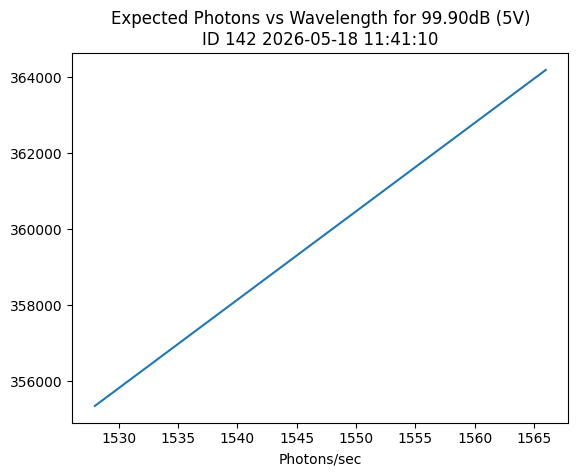

In [460]:
ID = 142
data = load_by_id(ID).get_parameter_data()
attenuation = data['attenuation']['attenuation']
Nphotons = data['Nphotons']['Nphotons']
wavelength = data['wavelength']['wavelength']
plt.plot(wavelength*1e9, Nphotons)
plt.title(params.make_title(ID=ID, title=f'Expected Photons vs Wavelength for {attenuation[0]:.2f}dB (5V)'))
plt.xlabel('Wavelength (nm)')
plt.xlabel('Photons/sec')

Check match:-1.4e-05 (test) = [-1.4e-05]?


Text(0.5, 1.0, 'SDE vs Wavelength\nID 141 2026-05-18 11:38:46\n5V')

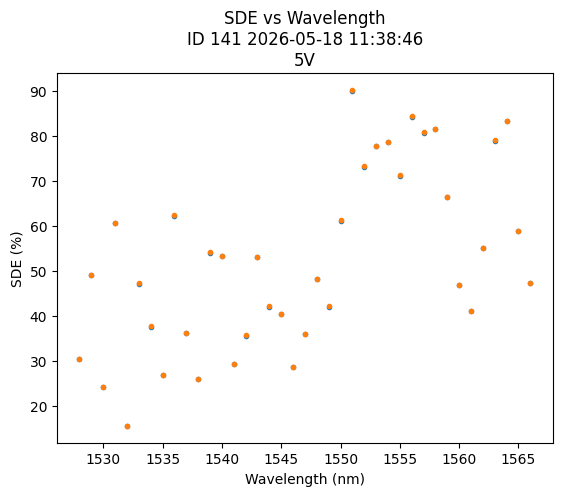

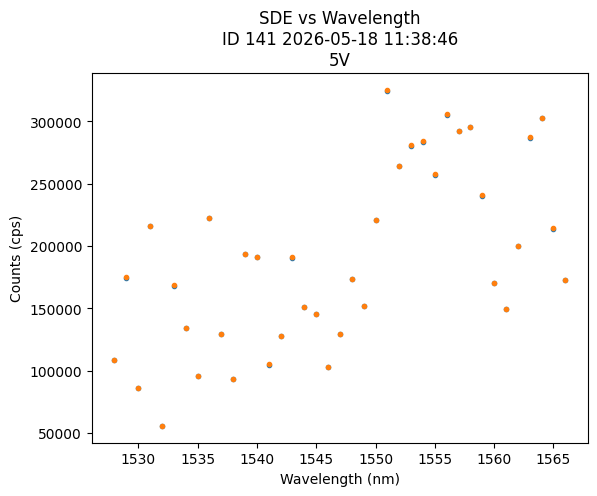

In [537]:
IDnphot = params.NphotonsID['vs_wav_5']
data = load_by_id(IDnphot).get_parameter_data()
attenuation = data['attenuation']['attenuation']
Nphotons5v_wav = data['Nphotons']['Nphotons']

# Get the corresponding current 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]


IDwav = params.device_line_1['IDs']['wavelength']['run5v']
data = load_by_id(IDwav).get_parameter_data()
wavelengths = data['wavelength_range']['wavelength_range']
light_counts1 = data['CR1']['CR1']
light_counts2 = data['CR2']['CR2']
total_counts1 = data['total_counts1']['total_counts1']

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons5v_wav
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons5v_wav
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE1, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='SDE vs Wavelength', extra='5V')
plt.title(title)

plt.figure()
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts1[~np.isnan(light_counts1)], '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts2[~np.isnan(light_counts2)], '.')
plt.ylabel('Counts (cps)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='SDE vs Wavelength', extra='5V')
plt.title(title)

Makes the vs Attenuation results look inconsistent

In [ ]:
IDwav = params.device_line_1['IDs']['wavelength']['run5v']
data = load_by_id(IDwav).get_parameter_data()
wavelengths = data['wavelength_range']['wavelength_range']
light_counts1 = data['CR1']['CR1']
light_counts2 = data['CR2']['CR2']
total_counts1 = data['total_counts1']['total_counts1']
# record power90 
# sweep around attenuator -> do you need to wait? Does the power waver? FOr the wavelength 
# wait time on detectors? 

Checking wavelength measurement

In [9]:
max_idx

39

In [ ]:

min_id = 144
max_id = 182

IDs = np.arange(min_id, max_id+1)

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])

min_idx=0
max_idx = len(IDs)

def plot_calibration_data(idx):
    ID = IDs[idx]
    wavelength = laser_wav_range[idx]
    
    data = load_by_id(ID).get_parameter_data()
    # plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
    plt.plot(data['times']['times'],data['power90']['power90'], '.')
    plt.title(f'Wavelength Sweep {params.att_blue_name}\n{wavelength*1e9:.1f}nm\nAvg: {params.avg_from_calibration(ID, key='attenuation'):.2f}dB')  
    # plt.ylabel('Attenuation (dB)')
    plt.ylabel('Power 90% Arm')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_calibration_data, idx=IntSlider(min_idx=min_idx, max_idx=max_idx, step=1, value=min_idx,
                                  continuous_update=False));



In [11]:
max_idx

39

In [ ]:
min_id = 144
max_id = 182

IDs = np.arange(min_id, max_id+1)

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])

min_idx=0
max_idx = len(IDs)

def plot_calibration_data(idx):
    ID = IDs[idx]
    wavelength = laser_wav_range[idx]
    
    data = load_by_id(ID).get_parameter_data()
    plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
    # plt.plot(data['times']['times'],data['power90']['power90'], '.')
    plt.title(f'Wavelength Sweep {params.att_blue_name}\n{wavelength*1e9:.1f}nm\nAvg: {params.avg_from_calibration(ID, key='attenuation'):.2f}dB')  
    plt.ylabel('Attenuation (dB)')
    # plt.ylabel('Power 90% Arm')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_calibration_data, idx=IntSlider(min_idx=min_idx, max_idx=max_idx, step=1, value=min_idx,
                                  continuous_update=False));



# Attenuation Check

In [2]:

min_id = 183
max_id = 225

IDs = np.arange(min_id, max_id+1)

v = params.att_blue_v_attenuator_range
v_att_range = np.arange(v['start'], v['stop'], v['step'])

min_idx=0
max_idx = len(IDs)

def plot_calibration_data(idx):
    ID = IDs[idx]
    v_att = v_att_range[idx]
    
    data = load_by_id(ID).get_parameter_data()
    plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
    # plt.plot(data['times']['times'],data['power90']['power90'], '.')
    plt.title(f' Attenuator Sweep {params.att_blue_name}\n{v_att:.2f}V\nAvg: {params.avg_from_calibration(ID, key='attenuation'):.2f}dB')  
    plt.ylabel('Attenuation (dB)')
    # plt.ylabel('Power 90% Arm')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_calibration_data, idx=IntSlider(min_idx=min_idx, max_idx=max_idx, step=1, value=min_idx,
                                  continuous_update=False));



interactive(children=(IntSlider(value=0, continuous_update=False, description='idx'), Output()), _dom_classes=…

In [7]:
len(IDs)

43

In [3]:

min_id = 183
max_id = 225

IDs = np.arange(min_id, max_id+1)

v = params.att_blue_v_attenuator_range
v_att_range = np.arange(v['start'], v['stop'], v['step'])

min_idx=0
max_idx = len(IDs)

def plot_calibration_data(idx):
    ID = IDs[idx]
    v_att = v_att_range[idx]
    
    data = load_by_id(ID).get_parameter_data()
    # plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
    plt.plot(data['times']['times'],data['power90']['power90'], '.')
    plt.title(f' Attenuator Sweep {params.att_blue_name}\n{v_att:.2f}V\nAvg: {params.avg_from_calibration(ID, key='attenuation'):.2f}dB')  
    # plt.ylabel('Attenuation (dB)')
    plt.ylabel('Power 90% Arm')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_calibration_data, idx=IntSlider(min_idx=min_idx, max_idx=max_idx, step=1, value=min_idx,
                                  continuous_update=False));



interactive(children=(IntSlider(value=0, continuous_update=False, description='idx'), Output()), _dom_classes=…

No indications from this that the photon number reaching the device would be inconsistent 

Current vs counts for various wavelengths

In [14]:
data = load_by_id(226).get_parameter_data()

In [20]:
data['wavelength']['wavelength']
current = data['CR1']['yoko_current']
CR1 = data['CR1']['CR1']
wav = data['wavelength']['wavelength']

Text(0.5, 1.0, '1540.00021574929')

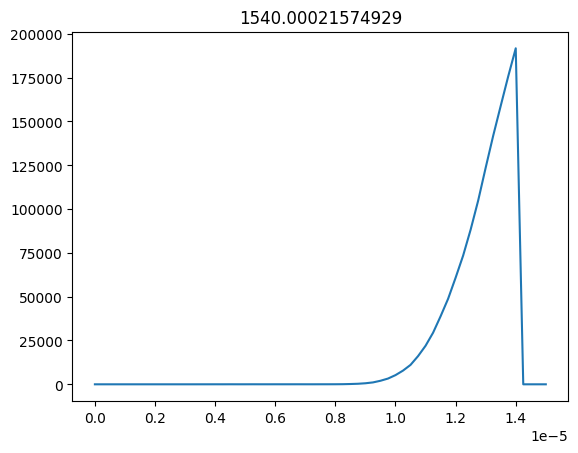

In [23]:
plt.plot(-current, CR1)
plt.title(wav[0]*1e9)

# Trace Capture

In [6]:
IDs_traces = params.device_line_1['IDs']['traces']
min_id = IDs_traces['start']
max_id = IDs_traces['stop']

def plot_traces(ID):
    plot_by_id(ID)
    data = load_by_id(ID).get_parameter_data()
    # trace = data['trace']['trace']
    # time_axis = data['time']['time']
    # plt.plot(time_axis, trace)
    current = data['yoko_current']['yoko_current']
    print(current)

interact(plot_traces, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));



interactive(children=(IntSlider(value=231, continuous_update=False, description='ID', max=235, min=231), Outpu…